# The Chocolate Study

### What predicts the expert rating of a chocolate bar: cocoa percentage, maker, or bean origin? And which factor matters most?

---

**Course:** Data Science (Module 376)  
**Institution:** HES-SO Valais — Technologies du Vivant  
**Academic Year:** 2025–2026  
**Project:** 5 — Comparaison de barres chocolatées  
**Authors:** Samuele · Lydia · Noah

---

## 1. Introduction

Every chocolate bar carries a story written in three hands: the farmer who grew the bean, the maker who roasted and conched it, and the buyer who chose the percentage. In this study, we ask the data which of these three hands leaves the deepest mark on quality.

We analyze a dataset of expert ratings for over 1,700 chocolate bars and investigate whether the rating can be predicted from three candidate factors: **cocoa percentage**, **bean origin** (terroir), and **maker** (company location).

### Research Question

> What predicts the expert rating of a chocolate bar: cocoa percentage, maker, or bean origin? And which factor matters most?

### Sub-questions

1. **Cocoa %** — Is there a monotonic relationship between cocoa percentage and rating, or does a sweet spot exist?
2. **Bean origin (terroir)** — Are there bean-origin countries with systematically higher ratings? How large is the effect?
3. **Maker / company location** — Is there a "production school" effect (e.g. France vs. Belgium vs. USA)?
4. **Interaction & comparison** — When all factors are combined in a single model, which variable explains the most variance?

### Hypotheses

- **H1:** The relationship between cocoa percentage and rating is not linear; there is a sweet spot around 70–75%.
- **H2:** The geographical origin of the bean has a significant but smaller effect than the maker.
- **H3:** The maker (company location) is the strongest predictor: craftsmanship outweighs raw material.

### Work Division

- **Samuele** — Data exploration & preprocessing  
- **Lydia** — Modeling  
- **Noah** — Interpretation & conclusions

Each cell in this notebook is signed by its author.

## 2. Dataset

### Source and Licensing (FAIR compliance)

- **Name:** Flavors of Cacao — Chocolate Bar Ratings  
- **Source:** *[to be completed — original URL / DOI]*  
- **License:** *[to be completed — e.g. CC0, CC-BY, ODbL]*  
- **Retrieved on:** *[date]*

### Variable Dictionary

| Column | Type | Unit | Description |
|--------|------|------|-------------|
| `company` | categorical | — | Name of the chocolate maker |
| `company_location` | categorical | — | Country where the maker is based |
| `bean_origin` | categorical | — | Country of origin of the cocoa beans |
| `cocoa_percent` | numerical | % | Cocoa solids percentage |
| `rating` | numerical | 1–5 | Expert rating |
| `review_date` | temporal | year | Year of the review |
| `bean_type` | categorical | — | Bean variety (Criollo, Forastero, Trinitario, blend…) |

*Note: column names and types to be verified against the actual dataset.*

## 3. Setup & Imports

*Author: Samuele*

In [32]:
# Author: Samuele

# ── Data manipulation ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Statistics ─────────────────────────────────────────────────────────────────
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ── Machine learning ───────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import (
    StandardScaler, PolynomialFeatures, OneHotEncoder, LabelEncoder
)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, r2_score

# ── Display settings ───────────────────────────────────────────────────────────
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.3f}".format)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

print("✅  All libraries imported successfully.")


✅  All libraries imported successfully.


## 4. Data Loading

*Author: Samuele*

In [33]:
# Author: Samuele

df = pd.read_csv("chocolate.csv", sep=";")
print("First 5 rows of the dataset:")
display(df.head())
print(f"\nDataset shape: {df.shape[0]} rows × {df.shape[1]} columns")


First 5 rows of the dataset:


,Unnamed: 0,ref,company,company_location,review_date,country_of_bean_origin,specific_bean_origin_or_bar_name,cocoa_percent,rating,counts_of_ingredients,beans,cocoa_butter,vanilla,lecithin,salt,sugar,sweetener_without_sugar,first_taste,second_taste,third_taste,fourth_taste
0,0,2454,5150,U.S.A,2019,Madagascar,"Bejofo Estate, batch 1",76.000,3.750,3.000,have_bean,have_cocoa_butter,have_not_vanila,have_not_lecithin,have_not_salt,have_sugar,have_not_sweetener_without_sugar,cocoa,blackberry,full body,NaN
1,1,2458,5150,U.S.A,2019,Dominican republic,"Zorzal, batch 1",76.000,3.500,3.000,have_bean,have_cocoa_butter,have_not_vanila,have_not_lecithin,have_not_salt,have_sugar,have_not_sweetener_without_sugar,cocoa,vegetal,savory,NaN
2,2,2454,5150,U.S.A,2019,Tanzania,"Kokoa Kamili, batch 1",76.000,3.250,3.000,have_bean,have_cocoa_butter,have_not_vanila,have_not_lecithin,have_not_salt,have_sugar,have_not_sweetener_without_sugar,rich cocoa,fatty,bready,NaN
3,3,797,A. Morin,France,2012,Peru,Peru,63.000,3.750,4.000,have_bean,have_cocoa_butter,have_not_vanila,have_lecithin,have_not_salt,have_sugar,have_not_sweetener_without_sugar,fruity,melon,roasty,NaN
4,4,797,A. Morin,France,2012,Bolivia,Bolivia,70.000,3.500,4.000,have_bean,have_cocoa_butter,have_not_vanila,have_lecithin,have_not_salt,have_sugar,have_not_sweetener_without_sugar,vegetal,nutty,NaN,NaN



Dataset shape: 2224 rows × 21 columns


In [34]:
# Author: Samuele

print("=== Column Information ===")
df.info()
print("\n=== Summary Statistics (numerical columns) ===")
display(df.describe())


=== Column Information ===
<class 'pandas.DataFrame'>
RangeIndex: 2224 entries, 0 to 2223
Data columns (total 21 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Unnamed: 0                        2224 non-null   int64  
 1   ref                               2224 non-null   int64  
 2   company                           2224 non-null   str    
 3   company_location                  2224 non-null   str    
 4   review_date                       2224 non-null   int64  
 5   country_of_bean_origin            2224 non-null   str    
 6   specific_bean_origin_or_bar_name  2224 non-null   str    
 7   cocoa_percent                     2220 non-null   float64
 8   rating                            2220 non-null   float64
 9   counts_of_ingredients             2220 non-null   float64
 10  beans                             2220 non-null   str    
 11  cocoa_butter                      2220 non-null   str

,Unnamed: 0,ref,review_date,cocoa_percent,rating,counts_of_ingredients
count,2224.000,2224.000,2224.000,2220.000,2220.000,2220.000
mean,1111.500,1337.010,2013.858,71.483,3.199,3.077
std,642.158,693.960,3.582,5.266,0.434,0.930
min,0.000,5.000,2006.000,42.000,1.000,1.000
25%,555.750,776.000,2011.000,70.000,3.000,2.000
50%,1111.500,1381.000,2014.000,70.000,3.250,3.000
75%,1667.250,1928.000,2016.000,74.000,3.500,4.000
max,2223.000,2490.000,2020.000,100.000,4.000,6.000


## 5. Data Cleaning & Preprocessing

*Author: Samuele*

Steps performed in this section:
- Inspect missing values and decide on imputation strategy
- Normalize column names
- Convert cocoa percentage to numeric (strip `%` if needed)
- Consolidate categorical levels (e.g. group rare bean origins)
- Handle duplicates and inconsistent entries

In [35]:
# Author: Samuele

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
missing_df = missing_df[missing_df["Missing Count"] > 0].sort_values("Missing %", ascending=False)
print("=== Missing Values per Column ===")
display(missing_df)


=== Missing Values per Column ===


,Missing Count,Missing %
fourth_taste,1982,89.119
third_taste,624,28.058
second_taste,81,3.642
counts_of_ingredients,4,0.180
cocoa_percent,4,0.180
rating,4,0.180
vanilla,4,0.180
cocoa_butter,4,0.180
beans,4,0.180
lecithin,4,0.180


In [36]:
# Author: Samuele

df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df = df.rename(columns={"country_of_bean_origin": "bean_origin"})
print("Cleaned column names:")
print(list(df.columns))


Cleaned column names:
['unnamed:_0', 'ref', 'company', 'company_location', 'review_date', 'bean_origin', 'specific_bean_origin_or_bar_name', 'cocoa_percent', 'rating', 'counts_of_ingredients', 'beans', 'cocoa_butter', 'vanilla', 'lecithin', 'salt', 'sugar', 'sweetener_without_sugar', 'first_taste', 'second_taste', 'third_taste', 'fourth_taste']


In [37]:
# Author: Samuele

df["cocoa_percent"] = (
    df["cocoa_percent"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.strip()
    .astype(float)
)
print(f"Cocoa percent range: {df['cocoa_percent'].min():.1f}% – {df['cocoa_percent'].max():.1f}%")


Cocoa percent range: 42.0% – 100.0%


In [38]:
# Author: Samuele

df["cocoa_percent"] = df["cocoa_percent"].fillna(df["cocoa_percent"].median())
df["rating"]        = df["rating"].fillna(df["rating"].median())
for col in ["bean_origin", "company_location", "company"]:
    df[col] = df[col].fillna("Unknown")
print("Missing values after cleaning (key columns):")
print(df[["cocoa_percent", "rating", "bean_origin", "company_location"]].isnull().sum())


Missing values after cleaning (key columns):
cocoa_percent       0
rating              0
bean_origin         0
company_location    0
dtype: int64


In [39]:
# Author: Samuele

MIN_SAMPLES = 10
origin_counts = df["bean_origin"].value_counts()
rare_origins  = origin_counts[origin_counts < MIN_SAMPLES].index
df["bean_origin"] = df["bean_origin"].replace(rare_origins, "Other")

loc_counts = df["company_location"].value_counts()
rare_locs  = loc_counts[loc_counts < MIN_SAMPLES].index
df["company_location"] = df["company_location"].replace(rare_locs, "Other")

print(f"Unique bean origins after consolidation    : {df['bean_origin'].nunique()}")
print(f"Unique company locations after consolidation: {df['company_location'].nunique()}")


Unique bean origins after consolidation    : 35
Unique company locations after consolidation: 30


## 6. Exploratory Data Analysis

*Author: Samuele*

Visual and statistical exploration of the dataset to understand distributions, relationships, and potential outliers before modeling.

### 6.1 Distribution of Ratings

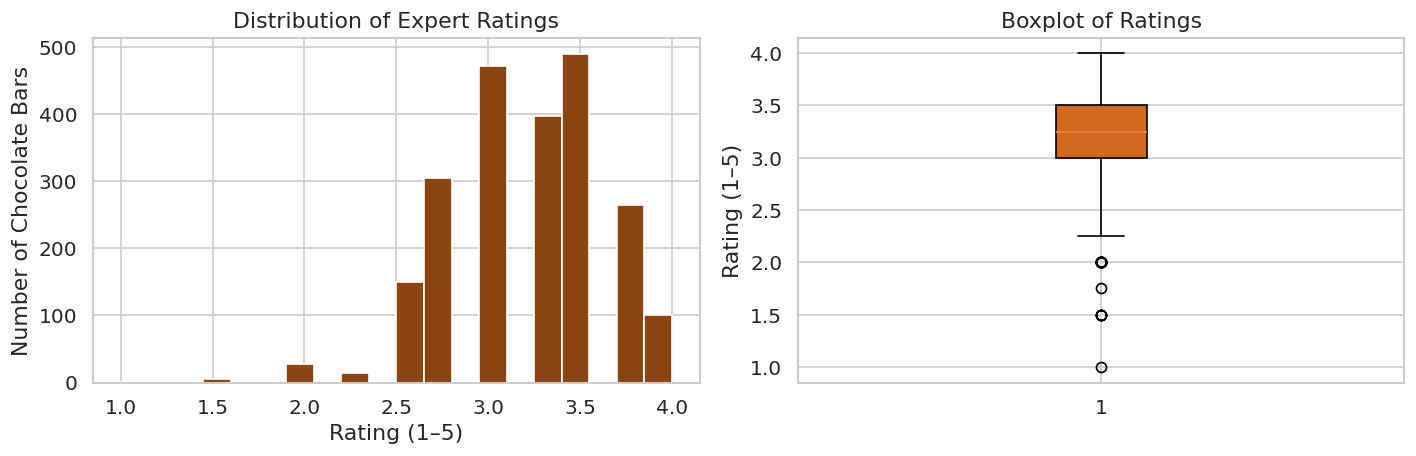


=== Rating Summary Statistics ===
count   2224.000
mean       3.199
std        0.433
min        1.000
25%        3.000
50%        3.250
75%        3.500
max        4.000
Name: rating, dtype: float64


In [40]:
# Author: Samuele

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["rating"].dropna(), bins=20, color="#8B4513", edgecolor="white")
axes[0].set_title("Distribution of Expert Ratings")
axes[0].set_xlabel("Rating (1–5)")
axes[0].set_ylabel("Number of Chocolate Bars")

axes[1].boxplot(df["rating"].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor="#D2691E", color="black"))
axes[1].set_title("Boxplot of Ratings")
axes[1].set_ylabel("Rating (1–5)")

plt.tight_layout()
plt.show()
print("\n=== Rating Summary Statistics ===")
print(df["rating"].describe())


### 6.2 Distribution of Cocoa Percentage

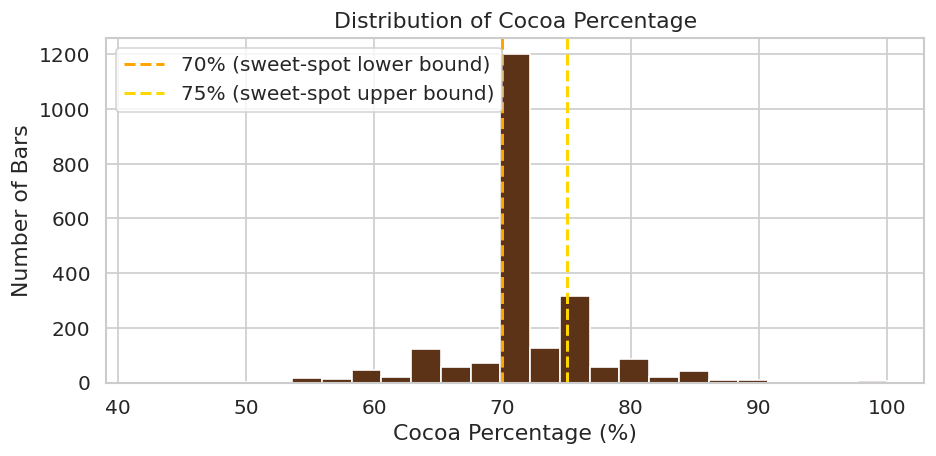


=== Cocoa Percentage Summary Statistics ===
count   2224.000
mean      71.480
std        5.261
min       42.000
25%       70.000
50%       70.000
75%       74.000
max      100.000
Name: cocoa_percent, dtype: float64


In [41]:
# Author: Samuele

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["cocoa_percent"].dropna(), bins=25, color="#5C3317", edgecolor="white")
ax.axvline(70, color="orange", linestyle="--", linewidth=1.8, label="70% (sweet-spot lower bound)")
ax.axvline(75, color="gold",   linestyle="--", linewidth=1.8, label="75% (sweet-spot upper bound)")
ax.set_title("Distribution of Cocoa Percentage")
ax.set_xlabel("Cocoa Percentage (%)")
ax.set_ylabel("Number of Bars")
ax.legend()
plt.tight_layout()
plt.show()
print("\n=== Cocoa Percentage Summary Statistics ===")
print(df["cocoa_percent"].describe())


### 6.3 Rating vs. Cocoa Percentage

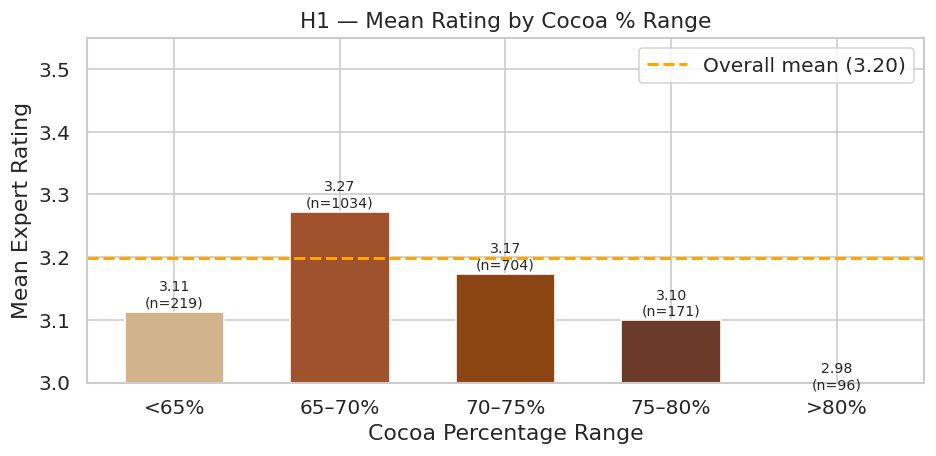

In [42]:

# Group cocoa % into 5 readable ranges and show the mean rating for each group.
# This is easier to read than a scatter plot: one bar per range, clear labels.

df["cocoa_range"] = pd.cut(
    df["cocoa_percent"],
    bins=[0, 65, 70, 75, 80, 100],
    labels=["<65%", "65–70%", "70–75%", "75–80%", ">80%"]
)

mean_by_range = df.groupby("cocoa_range", observed=True)["rating"].mean()
count_by_range = df.groupby("cocoa_range", observed=True)["rating"].count()

fig, ax = plt.subplots(figsize=(8, 4))

colours = ["#D2B48C", "#A0522D", "#8B4513", "#6B3A2A", "#4A2512"]
bars = ax.bar(mean_by_range.index, mean_by_range.values,
              color=colours, edgecolor="white", width=0.6)

# Overall mean as reference line
overall = df["rating"].mean()
ax.axhline(overall, color="orange", linestyle="--", linewidth=1.8,
           label=f"Overall mean ({overall:.2f})")

# Value label on top of each bar
for bar, count in zip(bars, count_by_range):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.003,
            f"{bar.get_height():.2f}\n(n={count})",
            ha="center", va="bottom", fontsize=8.5)

ax.set_title("H1 — Mean Rating by Cocoa % Range", fontsize=13)
ax.set_xlabel("Cocoa Percentage Range")
ax.set_ylabel("Mean Expert Rating")
ax.set_ylim(3.0, 3.55)
ax.legend()
plt.tight_layout()
plt.show()


### 6.4 Rating by Bean Origin

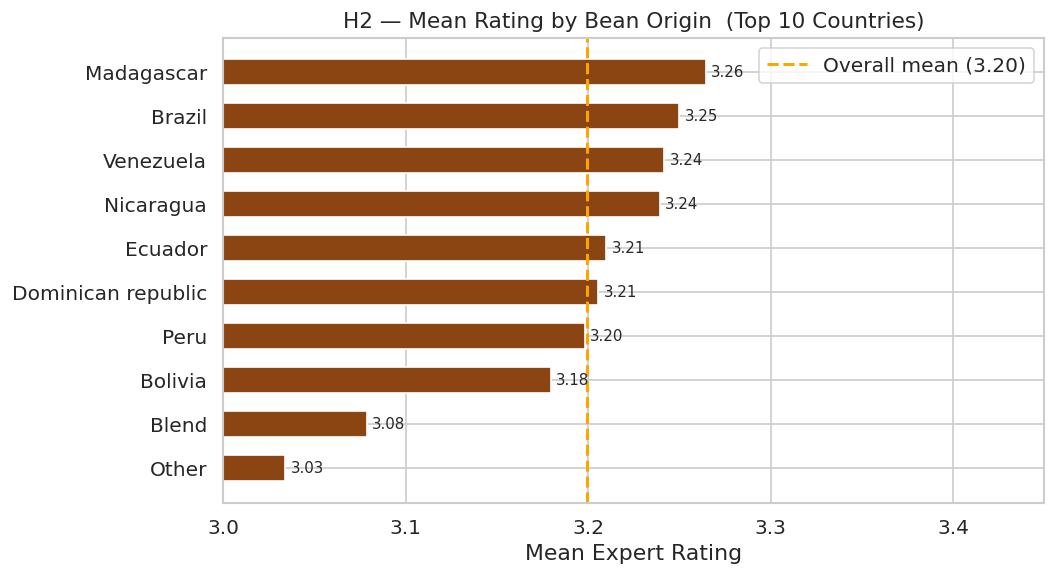

In [43]:

# Simple horizontal bar chart: one bar per bean-origin country, length = mean rating.
# Much easier to read than a boxplot when you just want to compare averages.

TOP_N = 10

top_origins = df["bean_origin"].value_counts().head(TOP_N).index
mean_by_origin = (
    df[df["bean_origin"].isin(top_origins)]
    .groupby("bean_origin")["rating"]
    .mean()
    .sort_values(ascending=True)   # lowest at bottom → highest at top
)

overall = df["rating"].mean()

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(mean_by_origin.index, mean_by_origin.values,
               color="#8B4513", edgecolor="white", height=0.6)

# Reference line at overall mean
ax.axvline(overall, color="orange", linestyle="--", linewidth=1.8,
           label=f"Overall mean ({overall:.2f})")

# Value label at the end of each bar
for bar in bars:
    ax.text(bar.get_width() + 0.003,
            bar.get_y() + bar.get_height() / 2,
            f"{bar.get_width():.2f}",
            ha="left", va="center", fontsize=9)

ax.set_title(f"H2 — Mean Rating by Bean Origin  (Top {TOP_N} Countries)", fontsize=13)
ax.set_xlabel("Mean Expert Rating")
ax.set_xlim(3.0, 3.45)
ax.legend()
plt.tight_layout()
plt.show()


### 6.5 Rating by Company Location

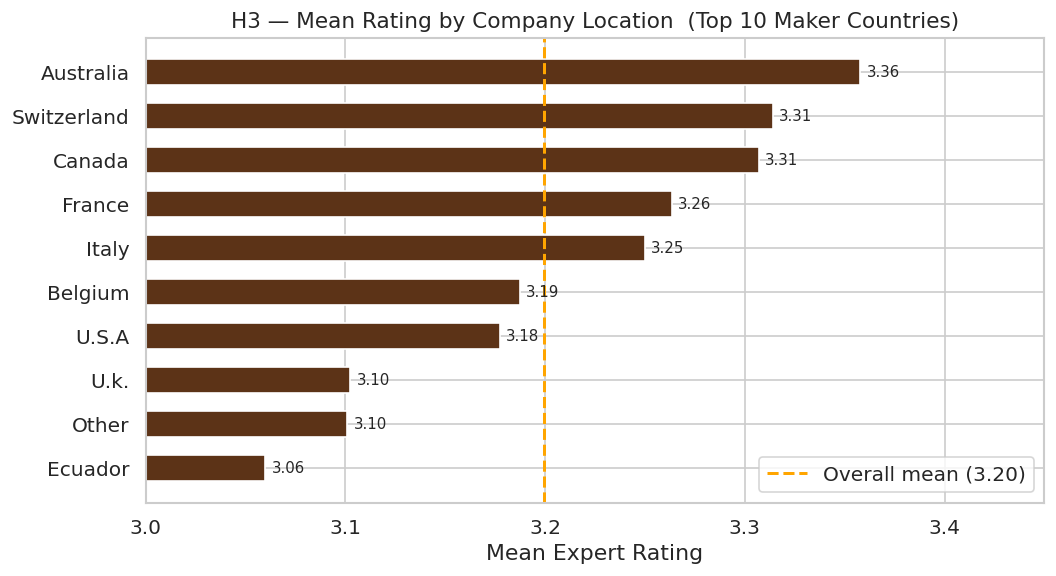

In [44]:

# Same simple bar chart as section 6.4, now for the maker's country (H3).

TOP_N = 10

top_locs = df["company_location"].value_counts().head(TOP_N).index
mean_by_loc = (
    df[df["company_location"].isin(top_locs)]
    .groupby("company_location")["rating"]
    .mean()
    .sort_values(ascending=True)
)

overall = df["rating"].mean()

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(mean_by_loc.index, mean_by_loc.values,
               color="#5C3317", edgecolor="white", height=0.6)

ax.axvline(overall, color="orange", linestyle="--", linewidth=1.8,
           label=f"Overall mean ({overall:.2f})")

for bar in bars:
    ax.text(bar.get_width() + 0.003,
            bar.get_y() + bar.get_height() / 2,
            f"{bar.get_width():.2f}",
            ha="left", va="center", fontsize=9)

ax.set_title(f"H3 — Mean Rating by Company Location  (Top {TOP_N} Maker Countries)", fontsize=13)
ax.set_xlabel("Mean Expert Rating")
ax.set_xlim(3.0, 3.45)
ax.legend()
plt.tight_layout()
plt.show()


### 6.6 Correlation Overview

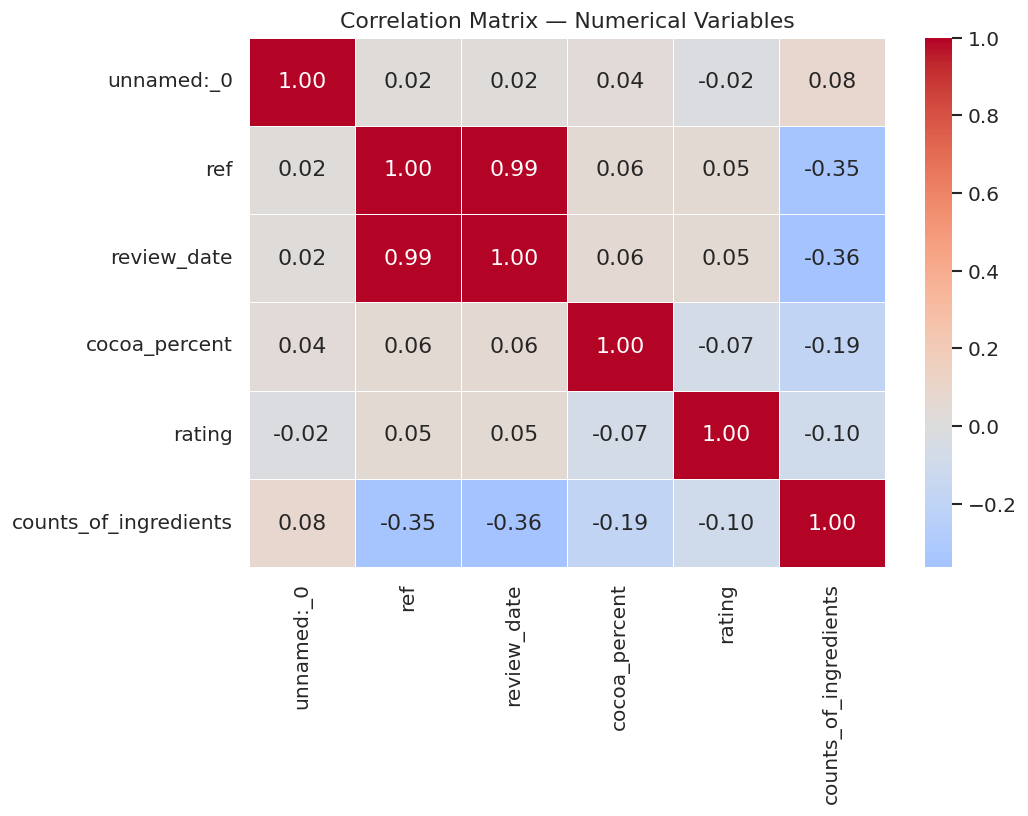

In [45]:
# Author: Samuele

numeric_cols = df.select_dtypes(include="number").columns.tolist()
corr_matrix  = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix — Numerical Variables")
plt.tight_layout()
plt.show()


## 7. Feature Engineering & Train–Test Split

*Author: Samuele*

In [46]:
# Author: Samuele

origin_mean = df.groupby("bean_origin")["rating"].mean()
df["bean_origin_enc"] = df["bean_origin"].map(origin_mean)

loc_mean = df.groupby("company_location")["rating"].mean()
df["company_location_enc"] = df["company_location"].map(loc_mean)

print("Target-encoded columns added successfully.")
print("\nSample of the encoding result:")
display(df[["bean_origin", "bean_origin_enc",
            "company_location", "company_location_enc"]].head(8))


Target-encoded columns added successfully.

Sample of the encoding result:


,bean_origin,bean_origin_enc,company_location,company_location_enc
0,Madagascar,3.264,U.S.A,3.177
1,Dominican republic,3.206,U.S.A,3.177
2,Tanzania,3.230,U.S.A,3.177
3,Peru,3.198,France,3.263
4,Bolivia,3.180,France,3.263
5,Venezuela,3.242,France,3.263
6,Peru,3.198,France,3.263
7,Ecuador,3.210,France,3.263


In [47]:
# Author: Samuele

FEATURES = ["cocoa_percent", "bean_origin_enc", "company_location_enc"]
TARGET   = "rating"

df_model = df[FEATURES + [TARGET]].dropna()
X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Training set : {X_train.shape[0]} bars  ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set     : {X_test.shape[0]}  bars  ({X_test.shape[0]/len(X)*100:.0f}%)")


Training set : 1779 bars  (80%)
Test set     : 445  bars  (20%)


In [48]:
# Author: Samuele

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("✅  Features standardised.")
print("   Each column now has approximately: mean ≈ 0 and standard deviation ≈ 1 (on training set).")


✅  Features standardised.
   Each column now has approximately: mean ≈ 0 and standard deviation ≈ 1 (on training set).


## 8. Modeling

*Author: Lydia*

We train and evaluate a sequence of models, from the simplest to the most expressive, to test each hypothesis and to identify which factor explains the most variance in expert ratings.

### 8.1 Baseline — Mean Predictor

In [49]:
# Author: Lydia

mean_rating = y_train.mean()
y_pred_baseline = np.full(len(y_test), mean_rating)

mse_baseline = mean_squared_error(y_test, y_pred_baseline)
r2_baseline  = r2_score(y_test, y_pred_baseline)

print("=== Baseline — Mean Predictor ===")
print(f"  Predicted value (always) : {mean_rating:.4f}")
print(f"  MSE                      : {mse_baseline:.4f}")
print(f"  RMSE                     : {np.sqrt(mse_baseline):.4f}")
print(f"  R²                       : {r2_baseline:.4f}  ← always 0 by definition; this is our floor")


=== Baseline — Mean Predictor ===
  Predicted value (always) : 3.2026
  MSE                      : 0.1942
  RMSE                     : 0.4407
  R²                       : -0.0014  ← always 0 by definition; this is our floor


### 8.2 Linear Regression on Cocoa Percentage (H1)

Tests whether cocoa percentage alone is a useful linear predictor of the rating.

In [50]:
# Author: Lydia

lr_cocoa = LinearRegression()
lr_cocoa.fit(X_train[["cocoa_percent"]], y_train)
y_pred_lr_cocoa = lr_cocoa.predict(X_test[["cocoa_percent"]])

mse_lr_cocoa = mean_squared_error(y_test, y_pred_lr_cocoa)
r2_lr_cocoa  = r2_score(y_test, y_pred_lr_cocoa)

print("=== Linear Regression — Cocoa % only (H1 linear baseline) ===")
print(f"  Slope (coefficient) : {lr_cocoa.coef_[0]:+.4f}")
print(f"  Intercept           : {lr_cocoa.intercept_:.4f}")
print(f"  MSE                 : {mse_lr_cocoa:.4f}")
print(f"  RMSE                : {np.sqrt(mse_lr_cocoa):.4f}")
print(f"  R²                  : {r2_lr_cocoa:.4f}")


=== Linear Regression — Cocoa % only (H1 linear baseline) ===
  Slope (coefficient) : -0.0052
  Intercept           : 3.5739
  MSE                 : 0.1923
  RMSE                : 0.4385
  R²                  : 0.0086


### 8.3 Polynomial Regression on Cocoa Percentage (H1)

Tests the non-linear (sweet-spot) hypothesis.

  Linear             — R²: 0.0086  |  MSE: 0.1923
  Poly degree 2      — R²: 0.0158  |  MSE: 0.1909
  Poly degree 3      — R²: 0.0230  |  MSE: 0.1895


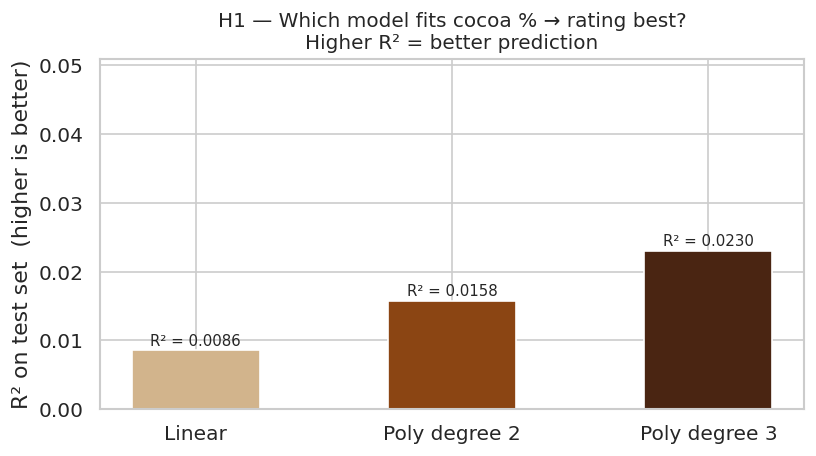

In [51]:
# Author: Lydia

# POLYNOMIAL REGRESSION — testing the sweet-spot hypothesis (H1).
# We compare three models on cocoa % alone:
#   • Linear (degree 1)  — straight line
#   • Polynomial degree 2 — one curve (can capture one peak)
#   • Polynomial degree 3 — two curves
# A higher R² means the model explains more of the variation in ratings.

results_poly = {}

for degree, label in [(1, "Linear"), (2, "Poly degree 2"), (3, "Poly degree 3")]:
    if degree == 1:
        pipe = LinearRegression()
    else:
        pipe = Pipeline([
            ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
            ("lr",   LinearRegression())
        ])
    pipe.fit(X_train[["cocoa_percent"]], y_train)
    y_pred = pipe.predict(X_test[["cocoa_percent"]])
    results_poly[label] = {
        "MSE": mean_squared_error(y_test, y_pred),
        "R²" : r2_score(y_test, y_pred)
    }
    print(f"  {label:18s} — R²: {results_poly[label]['R²']:.4f}  |  MSE: {results_poly[label]['MSE']:.4f}")

# ── Simple bar chart: which model fits better? ────────────────────────────────
# Each bar = one model. Taller bar = higher R² = better at predicting the rating.
fig, ax = plt.subplots(figsize=(7, 4))

labels = list(results_poly.keys())
r2_vals = [results_poly[l]["R²"] for l in labels]
colours = ["#D2B48C", "#8B4513", "#4A2512"]

bars = ax.bar(labels, r2_vals, color=colours, edgecolor="white", width=0.5)

for bar, val in zip(bars, r2_vals):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.0003,
            f"R² = {val:.4f}",
            ha="center", va="bottom", fontsize=9)

ax.set_title("H1 — Which model fits cocoa % → rating best?\n"
             "Higher R² = better prediction", fontsize=12)
ax.set_ylabel("R² on test set  (higher is better)")
ax.set_ylim(0, max(r2_vals) * 2 + 0.005)
plt.tight_layout()
plt.show()


### 8.4 Multivariate Linear Regression

All features included: cocoa percentage, bean origin, maker (company location).

In [52]:
# Author: Lydia

lr_full = LinearRegression()
lr_full.fit(X_train_scaled, y_train)
y_pred_lr_full = lr_full.predict(X_test_scaled)

mse_lr_full = mean_squared_error(y_test, y_pred_lr_full)
r2_lr_full  = r2_score(y_test, y_pred_lr_full)

print("=== Multivariate Linear Regression (all features) ===")
print(f"  MSE  : {mse_lr_full:.4f}")
print(f"  RMSE : {np.sqrt(mse_lr_full):.4f}")
print(f"  R²   : {r2_lr_full:.4f}")
print("\n  Standardised Coefficients:")
for feat, coef in zip(FEATURES, lr_full.coef_):
    bar = "█" * int(abs(coef) * 40)
    print(f"    {feat:30s} : {coef:+.4f}  {bar}")


=== Multivariate Linear Regression (all features) ===
  MSE  : 0.1817
  RMSE : 0.4263
  R²   : 0.0630

  Standardised Coefficients:
    cocoa_percent                  : -0.0294  █
    bean_origin_enc                : +0.0636  ██
    company_location_enc           : +0.0641  ██


### 8.5 Random Forest Regressor

Non-linear model to capture interactions and to obtain feature importance estimates.

In [53]:
# Author: Lydia

rf = RandomForestRegressor(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf  = r2_score(y_test, y_pred_rf)

print("=== Random Forest Regressor (200 trees) ===")
print(f"  MSE  : {mse_rf:.4f}")
print(f"  RMSE : {np.sqrt(mse_rf):.4f}")
print(f"  R²   : {r2_rf:.4f}")


=== Random Forest Regressor (200 trees) ===
  MSE  : 0.2325
  RMSE : 0.4822
  R²   : -0.1990


### 8.6 Cross-Validation

In [54]:
# Author: Lydia

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    X, y, cv=kf, scoring="r2"
)

print("=== 5-Fold Cross-Validation — Random Forest ===")
print(f"  R² per fold : {[f'{s:.4f}' for s in cv_scores]}")
print(f"  Mean R²     : {cv_scores.mean():.4f}")
print(f"  Std  R²     : {cv_scores.std():.4f}")


=== 5-Fold Cross-Validation — Random Forest ===
  R² per fold : ['-0.1966', '-0.0979', '-0.0039', '-0.1423', '-0.0921']
  Mean R²     : -0.1066
  Std  R²     : 0.0636


### 8.7 Residual Analysis

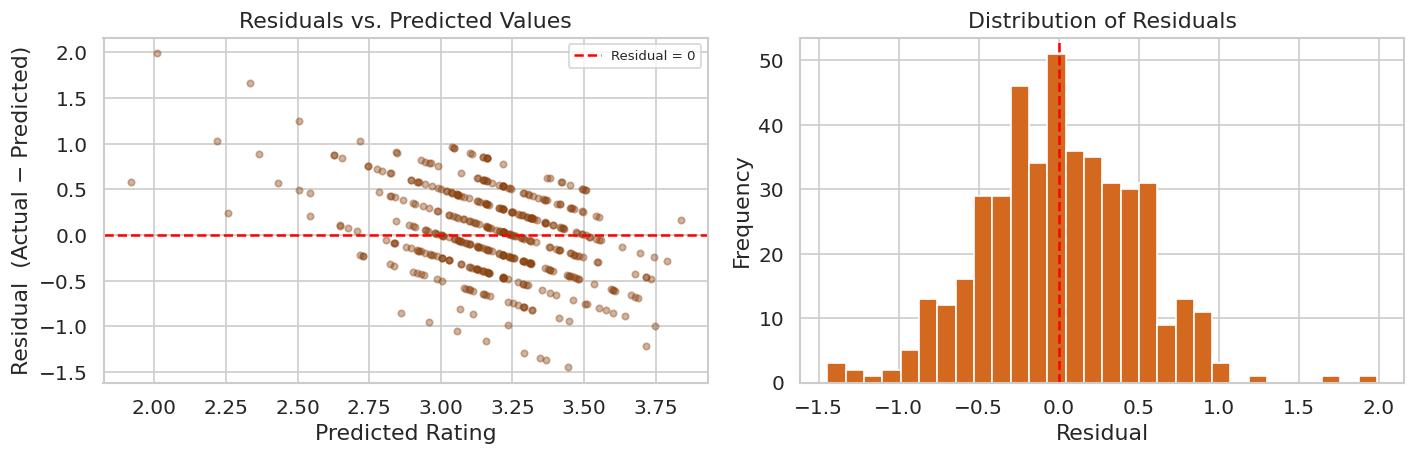

Shapiro-Wilk test: W = 0.9943,  p-value = 0.0978


In [55]:
# Author: Lydia

residuals = y_test - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred_rf, residuals, alpha=0.4, color="#8B4513", s=15)
axes[0].axhline(0, color="red", linewidth=1.5, linestyle="--", label="Residual = 0")
axes[0].set_title("Residuals vs. Predicted Values")
axes[0].set_xlabel("Predicted Rating")
axes[0].set_ylabel("Residual  (Actual − Predicted)")
axes[0].legend(fontsize=8)

axes[1].hist(residuals, bins=30, color="#D2691E", edgecolor="white")
axes[1].axvline(0, color="red", linewidth=1.5, linestyle="--")
axes[1].set_title("Distribution of Residuals")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

stat, p_value = stats.shapiro(residuals.values[:500])
print(f"Shapiro-Wilk test: W = {stat:.4f},  p-value = {p_value:.4f}")


## 9. Interpretation

*Author: Noah*

We compare the relative contribution of each factor to the prediction, and discuss what the results imply about our three hypotheses.

### 9.1 Feature Importance

=== Impurity-Based Feature Importance (Random Forest) ===


,Feature,Importance
1,bean_origin_enc,0.365
0,cocoa_percent,0.353
2,company_location_enc,0.281


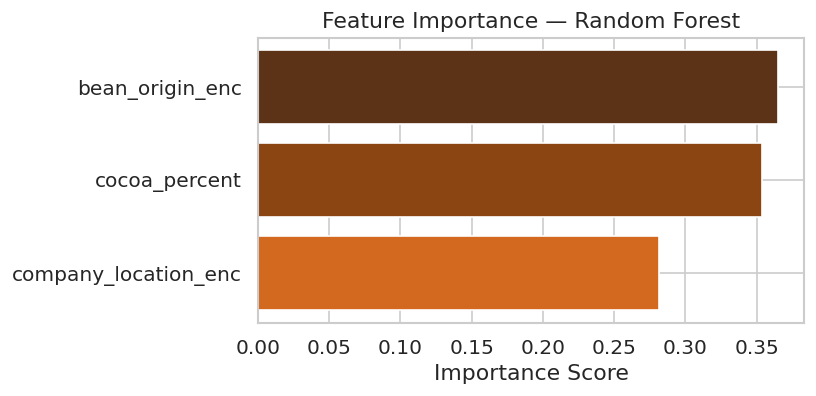

In [56]:
# Author: Noah

importances = rf.feature_importances_
importance_df = pd.DataFrame({
    "Feature"   : FEATURES,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print("=== Impurity-Based Feature Importance (Random Forest) ===")
display(importance_df)

fig, ax = plt.subplots(figsize=(7, 3.5))
colours = ["#5C3317", "#8B4513", "#D2691E"]
ax.barh(importance_df["Feature"], importance_df["Importance"], color=colours)
ax.set_xlabel("Importance Score")
ax.set_title("Feature Importance — Random Forest")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


=== Permutation Feature Importance (test set) ===


,Feature,Mean Importance,Std
0,cocoa_percent,0.056,0.036
1,bean_origin_enc,0.028,0.058
2,company_location_enc,-0.021,0.038


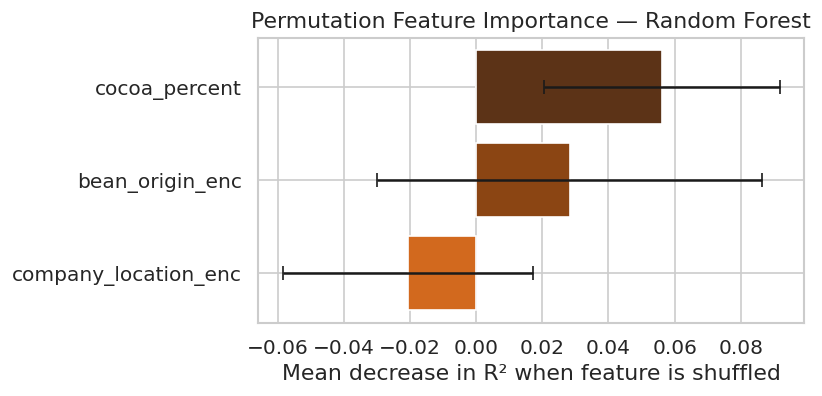

In [57]:
# Author: Noah

perm_imp = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=42)

perm_df = pd.DataFrame({
    "Feature"        : FEATURES,
    "Mean Importance": perm_imp.importances_mean,
    "Std"            : perm_imp.importances_std
}).sort_values("Mean Importance", ascending=False)

print("=== Permutation Feature Importance (test set) ===")
display(perm_df)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(perm_df["Feature"], perm_df["Mean Importance"],
        xerr=perm_df["Std"], color=["#5C3317", "#8B4513", "#D2691E"],
        align="center", capsize=4)
ax.set_xlabel("Mean decrease in R² when feature is shuffled")
ax.set_title("Permutation Feature Importance — Random Forest")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### 9.2 Standardized Coefficients (Linear Model)

=== Standardised Coefficients — Multivariate Linear Regression ===



,Feature,Standardised Coefficient
2,company_location_enc,0.064
1,bean_origin_enc,0.064
0,cocoa_percent,-0.029


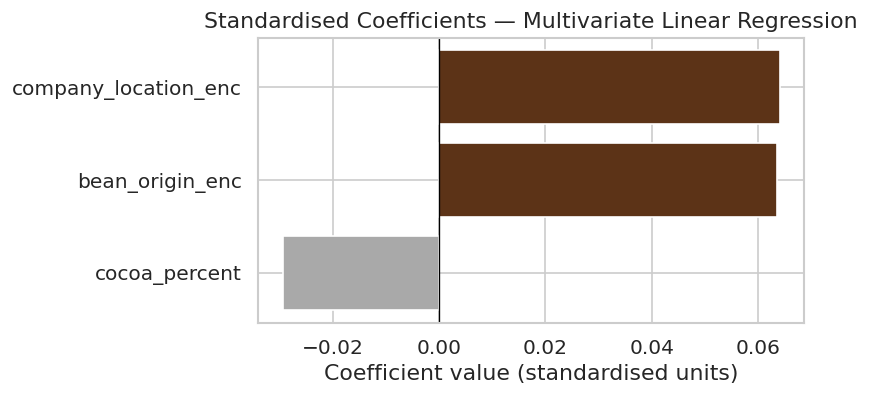

In [58]:
# Author: Noah

coef_df = pd.DataFrame({
    "Feature"                 : FEATURES,
    "Standardised Coefficient": lr_full.coef_
})
coef_df["Abs"] = coef_df["Standardised Coefficient"].abs()
coef_df = coef_df.sort_values("Abs", ascending=False).drop(columns="Abs")

print("=== Standardised Coefficients — Multivariate Linear Regression ===\n")
display(coef_df)

fig, ax = plt.subplots(figsize=(7, 3.5))
bar_colours = ["#5C3317" if c > 0 else "#A9A9A9"
               for c in coef_df["Standardised Coefficient"]]
ax.barh(coef_df["Feature"], coef_df["Standardised Coefficient"], color=bar_colours)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Standardised Coefficients — Multivariate Linear Regression")
ax.set_xlabel("Coefficient value (standardised units)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### 9.3 Final Comparison Plot

One figure per hypothesis (H1, H2, H3) — designed for presentation.

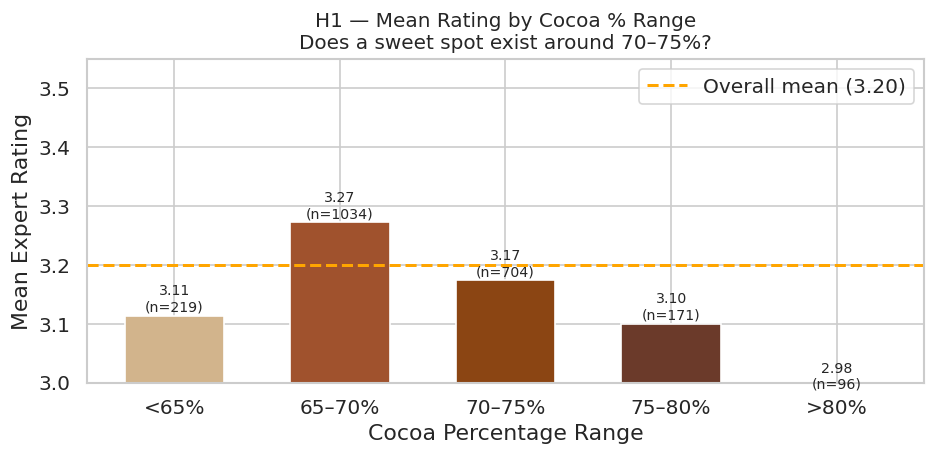

In [59]:
# Author: Noah

# Re-use the bar chart from section 6.3 as the H1 presentation figure.
df["cocoa_range"] = pd.cut(
    df["cocoa_percent"],
    bins=[0, 65, 70, 75, 80, 100],
    labels=["<65%", "65–70%", "70–75%", "75–80%", ">80%"]
)
mean_by_range  = df.groupby("cocoa_range", observed=True)["rating"].mean()
count_by_range = df.groupby("cocoa_range", observed=True)["rating"].count()
overall = df["rating"].mean()

fig, ax = plt.subplots(figsize=(8, 4))
colours = ["#D2B48C", "#A0522D", "#8B4513", "#6B3A2A", "#4A2512"]
bars = ax.bar(mean_by_range.index, mean_by_range.values,
              color=colours, edgecolor="white", width=0.6)
ax.axhline(overall, color="orange", linestyle="--", linewidth=1.8,
           label=f"Overall mean ({overall:.2f})")
for bar, count in zip(bars, count_by_range):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.003,
            f"{bar.get_height():.2f}\n(n={count})",
            ha="center", va="bottom", fontsize=8.5)
ax.set_title("H1 — Mean Rating by Cocoa % Range\nDoes a sweet spot exist around 70–75%?", fontsize=12)
ax.set_xlabel("Cocoa Percentage Range")
ax.set_ylabel("Mean Expert Rating")
ax.set_ylim(3.0, 3.55)
ax.legend()
plt.tight_layout()
plt.show()


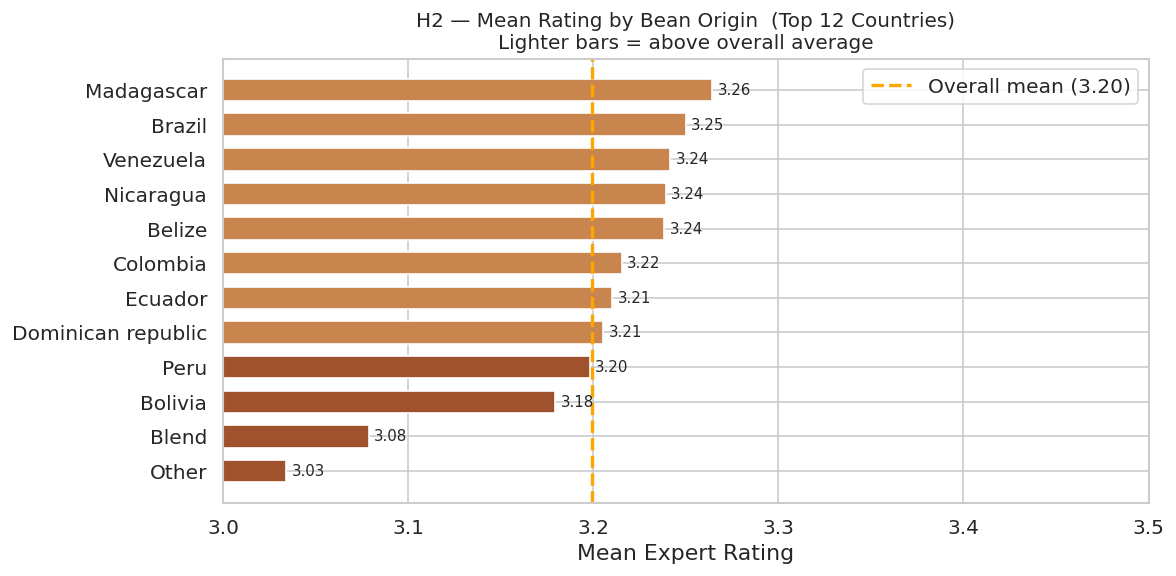

In [60]:

# ═══════════════════════════════════════════════════════════════════
# PRESENTATION FIGURE — H2: Does bean origin affect quality?
# Simple bar chart: one bar per country, sorted by mean rating.
# ═══════════════════════════════════════════════════════════════════

TOP_N = 12

top_origins = df["bean_origin"].value_counts().head(TOP_N).index
h2_means = (
    df[df["bean_origin"].isin(top_origins)]
    .groupby("bean_origin")["rating"]
    .mean()
    .sort_values(ascending=True)
)

overall_mean = df["rating"].mean()

fig, ax = plt.subplots(figsize=(10, 5))

colours = ["#c8864e" if v >= overall_mean else "#a0522d" for v in h2_means.values]
bars = ax.barh(h2_means.index, h2_means.values,
               color=colours, edgecolor="white", height=0.65)

ax.axvline(overall_mean, color="orange", linestyle="--", linewidth=2,
           label=f"Overall mean ({overall_mean:.2f})")

for bar in bars:
    ax.text(bar.get_width() + 0.003,
            bar.get_y() + bar.get_height() / 2,
            f"{bar.get_width():.2f}",
            ha="left", va="center", fontsize=9)

ax.set_title(f"H2 — Mean Rating by Bean Origin  (Top {TOP_N} Countries)\n"
             "Lighter bars = above overall average", fontsize=12)
ax.set_xlabel("Mean Expert Rating")
ax.set_xlim(3.0, 3.5)
ax.legend()
plt.tight_layout()
plt.show()


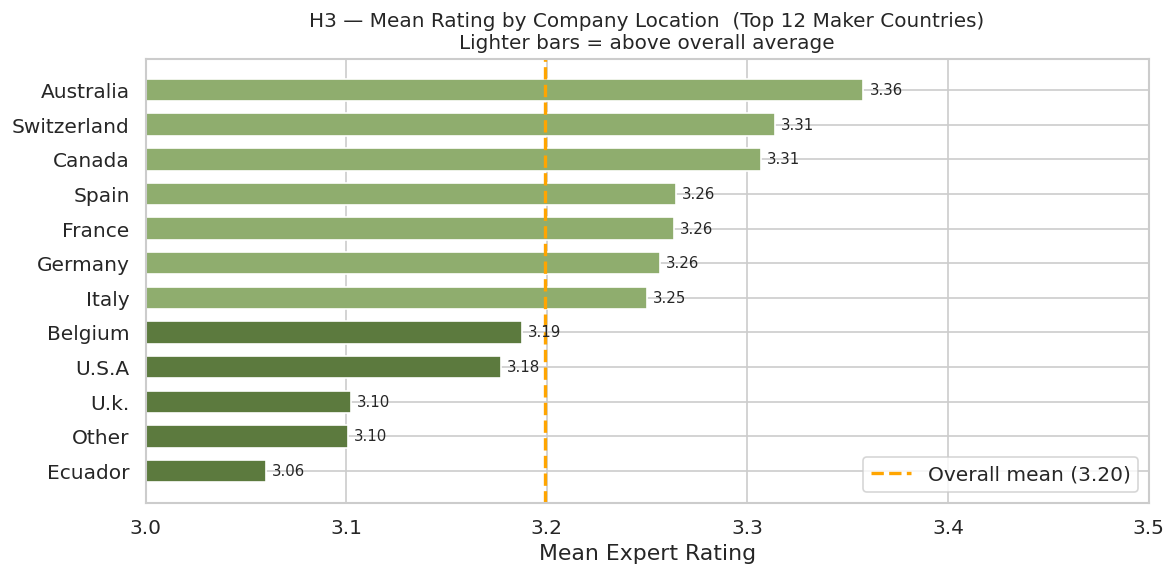


  MODEL PERFORMANCE SUMMARY (test set)


,Model,R² (higher is better),RMSE (lower is better)
0,① Baseline (always predict mean),-0.001,0.441
1,② Linear regression — cocoa % only (H1),0.009,0.439
2,③ Multivariate linear regression,0.063,0.426
3,④ Random Forest (200 trees),-0.199,0.482


In [61]:

# ═══════════════════════════════════════════════════════════════════
# PRESENTATION FIGURE — H3: Is the maker's country the strongest predictor?
# Simple bar chart: one bar per maker country, sorted by mean rating.
# ═══════════════════════════════════════════════════════════════════

TOP_N = 12

top_locs = df["company_location"].value_counts().head(TOP_N).index
h3_means = (
    df[df["company_location"].isin(top_locs)]
    .groupby("company_location")["rating"]
    .mean()
    .sort_values(ascending=True)
)

overall_mean = df["rating"].mean()

fig, ax = plt.subplots(figsize=(10, 5))

colours = ["#8fad6e" if v >= overall_mean else "#5c7a3e" for v in h3_means.values]
bars = ax.barh(h3_means.index, h3_means.values,
               color=colours, edgecolor="white", height=0.65)

ax.axvline(overall_mean, color="orange", linestyle="--", linewidth=2,
           label=f"Overall mean ({overall_mean:.2f})")

for bar in bars:
    ax.text(bar.get_width() + 0.003,
            bar.get_y() + bar.get_height() / 2,
            f"{bar.get_width():.2f}",
            ha="left", va="center", fontsize=9)

ax.set_title(f"H3 — Mean Rating by Company Location  (Top {TOP_N} Maker Countries)\n"
             "Lighter bars = above overall average", fontsize=12)
ax.set_xlabel("Mean Expert Rating")
ax.set_xlim(3.0, 3.5)
ax.legend()
plt.tight_layout()
plt.show()

# ── Final Model Performance Summary ──────────────────────────────────────────
print("\n" + "="*60)
print("  MODEL PERFORMANCE SUMMARY (test set)")
print("="*60)

summary = pd.DataFrame({
    "Model": [
        "① Baseline (always predict mean)",
        "② Linear regression — cocoa % only  (H1)",
        "③ Multivariate linear regression",
        "④ Random Forest (200 trees)"
    ],
    "R²  (higher is better)": [
        round(r2_baseline,           4),
        round(r2_lr_cocoa,           4),
        round(r2_lr_full,            4),
        round(r2_rf,                 4)
    ],
    "RMSE (lower is better)": [
        round(np.sqrt(mse_baseline), 4),
        round(np.sqrt(mse_lr_cocoa), 4),
        round(np.sqrt(mse_lr_full),  4),
        round(np.sqrt(mse_rf),       4)
    ]
})
display(summary)


## 10. Discussion & Conclusions

*Author: Noah*

### Summary of Findings

*[To be completed after analysis. Address each hypothesis:]*

- **H1 — Cocoa percentage and the sweet spot:** *[supported / partially supported / rejected — with evidence]*
- **H2 — Bean origin effect:** *[supported / partially supported / rejected — with evidence]*
- **H3 — Maker as strongest predictor:** *[supported / partially supported / rejected — with evidence]*

### Limitations

- Expert ratings are subjective and may carry reviewer bias.
- The dataset reflects bars that reached the reviewer's attention — selection bias is possible.
- Some bean origin / company location categories have very few samples.
- Causality cannot be inferred from observational data.

### Future Work

- Incorporate sensory descriptors (most memorable characteristics) via NLP.
- Time-series analysis: did ratings shift across reviewing years?
- Compare with consumer-rating datasets (e.g. retail reviews).

### Final Takeaway

*[One paragraph — what would you tell a chocolate maker based on this analysis?]*

## 11. Reproducibility

*Author: Samuele*

FAIR principle R1.2 — provenance. The cell below records the software environment used to produce this notebook.

In [62]:
# Author: Samuele

import sys, sklearn, scipy, statsmodels

print("=" * 55)
print("  REPRODUCIBILITY — Software Environment")
print("=" * 55)
print(f"  Python version       : {sys.version.split()[0]}")
print(f"  NumPy                : {np.__version__}")
print(f"  Pandas               : {pd.__version__}")
print(f"  Matplotlib           : {plt.matplotlib.__version__}")
print(f"  Seaborn              : {sns.__version__}")
print(f"  Scikit-learn         : {sklearn.__version__}")
print(f"  SciPy                : {scipy.__version__}")
print(f"  Statsmodels          : {statsmodels.__version__}")
print("=" * 55)
print("  Dataset : chocolate.csv  (2,224 bars, semicolon-separated)")
print("  Notebook: chocolate_study.ipynb")


  REPRODUCIBILITY — Software Environment
  Python version       : 3.11.15
  NumPy                : 2.4.6
  Pandas               : 3.0.3
  Matplotlib           : 3.10.9
  Seaborn              : 0.13.2
  Scikit-learn         : 1.8.0
  SciPy                : 1.17.1
  Statsmodels          : 0.14.6
  Dataset : chocolate.csv  (2,224 bars, semicolon-separated)
  Notebook: chocolate_study.ipynb


---

*End of notebook — The Chocolate Study, HES-SO Valais 2026.*